In [1]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
})

In [ ]:
benchmark_sizes = {
    "hotpotqa": 179,
    "synthetic": 100,
    "musique": 135,
    "2wiki": 144
}

KG_sizes = {
    "hotpotqa": 227491,
    "synthetic": 1834,
    "2wiki": 8081
}

In [3]:
def load_results(results_dir: str) -> list[dict]:
    results = []
    for f in Path(results_dir).glob("*.json"):
        with open(f, "r", encoding="utf-8") as fh:
            results.append(json.load(fh))
    return results


def context_size(r: dict) -> int:
    entities = len(r["original_subgraph"].get("entities", []))
    relations = len(r["original_subgraph"].get("relations", []))
    return entities + relations


def setup_plot_style() -> None:
    sns.set_theme(
        style="whitegrid",
        rc={
            "grid.linestyle": "--",
            "grid.alpha": 0.4,
        },
    )

def _avg_metrics(results: list[dict]) -> tuple[float, float]:
    found = [r for r in results if r["found"]]
    avg_time = np.mean([r["timings"]["total_seconds"] for r in results])
    avg_ops  = np.mean([r["num_operations"] for r in found]) if found else 0.0
    return avg_time, avg_ops

In [ ]:
def plot_benchmark_vs_metrics(
    results_by_benchmark: dict[str, list[dict]],
    benchmark_sizes: dict[str, int],
    output: str = "benchmark_vs_metrics.pdf",
):
    """Plot avg response time vs benchmark size (KG-style scatter logic)."""

    plt.figure(figsize=(8, 7))

    for benchmark, results in results_by_benchmark.items():
        avg_time, _ = _avg_metrics(results)
        size = benchmark_sizes[benchmark]

        plt.scatter(size, avg_time)

        plt.annotate(
            benchmark.upper(),
            (size, avg_time),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=14,
        )

    plt.xlim(0, 150)
    plt.xlabel("Benchmark Size", fontsize=20, labelpad=10)
    plt.ylabel(r"Avg Response Time (s) / Explanation", fontsize=20, labelpad=10)
    plt.grid(True, linestyle="--", alpha=0.4)

    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

    plt.tight_layout()
    # plt.savefig(output, dpi=150, bbox_inches="tight")
    plt.savefig(output, format="pdf", dpi=300)
    plt.show()

    print(f"Saved to {output}")

In [ ]:
def plot_kg_size_vs_response_time(
    results_by_benchmark: dict[str, list[dict]],
    kg_sizes: dict[str, int],
    output: str = "kg_size_vs_response_time.pdf",
):
    """Plot avg response time vs KG size."""

    plt.figure(figsize=(8, 7))

    xmax = max(kg_sizes.values())

    for benchmark, results in results_by_benchmark.items():
        avg_time, _ = _avg_metrics(results)
        kg_size = kg_sizes[benchmark]

        plt.scatter(kg_size, avg_time)

        if kg_size > 0.6 * xmax:
            dx, ha = -10, "right"
        else:
            dx, ha = 5, "left"

        plt.annotate(
            benchmark.upper(),
            (kg_size, avg_time),
            xytext=(dx, 5),
            textcoords="offset points",
            ha=ha,
            fontsize=14,
            clip_on=True
        )

    plt.xlabel("KG Size", fontsize=20, labelpad=10)
    plt.xscale("log")
    plt.ylabel(r"Avg Response Time (s) / Explanation", fontsize=20, labelpad=10)
    plt.ylim(0, 100)
    plt.grid(True, which="both", linestyle="--", alpha=0.4)

    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

    plt.tight_layout()
    plt.savefig(output, format="pdf")
    plt.show()

    print(f"Saved to {output}")

In [ ]:
def plot_context_vs_time_multi(
    dataset_results: dict[str, list[dict]],
    output: str = "context_vs_time.pdf",
) -> None:
    setup_plot_style()

    palette = sns.color_palette("husl", n_colors=len(dataset_results))

    fig, ax = plt.subplots(figsize=(7, 5))

    for (dataset, results), color in zip(dataset_results.items(), palette):
        pairs = [(r, context_size(r), r["timings"]["total_seconds"])
         for r in results if r.get("found") is not False]
        xs = np.array([p[1] for p in pairs])
        ys = np.array([p[2] for p in pairs])

        sns.regplot(
            x=xs, y=ys, ax=ax,
            ci=None,
            scatter=False,
            line_kws={
                "color": color,
                "linewidth": 3.5,        
                "linestyle": "dashed",    
                "alpha": 1.0,
                "zorder": 4,             
            },
        )

        ax.scatter(
            xs, ys,
            marker="o",
            s=40,
            facecolors=(*color, 0.25),   
            edgecolors=(*color, 0.6),    
            linewidths=0.5,
            label=dataset,
            zorder=3,
        )

    ax.set_xlabel(r"Context size $|V_C| + |E_C|$", fontsize=20, labelpad=10)
    ax.set_ylabel("Response Time (s)", fontsize=20, labelpad=10)
    ax.legend(fontsize=12, title="Dataset", title_fontsize=13)

    plt.tick_params(axis='x', labelsize=15)
    plt.tick_params(axis='y', labelsize=15)

    plt.tight_layout()
    plt.savefig(output, format="pdf", dpi=300)
    plt.show()

    print(f"Saved to {output}")

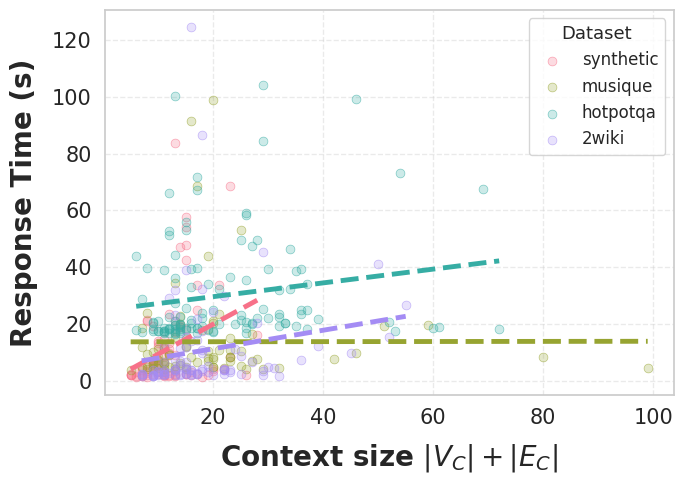

Saved to context_vs_time_multi.pdf


In [17]:
datasets = [
    "synthetic",
    "musique",
    "hotpotqa",
    "2wiki"
]

dataset_results = {}
for dataset in datasets:
    ft_case = f"../counterfactuals/results/{dataset}/delete_ops_ft"
    ff_case = f"../counterfactuals/results/{dataset}/all_ops_ff"
    dataset_results[dataset] = load_results(ft_case) + load_results(ff_case)

plot_context_vs_time_multi(dataset_results, output="context_vs_time_multi.pdf")